In [ ]:
!pip install datetime pandas matplotlib fastdtw imutils geopy pyproj easydict opencv-python

In [ ]:
!pip -q install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [ ]:
import torch
print(torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

In [ ]:
import torch
torch.__version__

In [3]:
import os
print(os.getcwd())

C:\Users\AIS-DT-Power4\PycharmProjects\PythonProject1\DeepSORVF


In [ ]:
os.path.exists('clip-01/2022_06_04_12_05_12_12_07_02_b.mp4')

In [ ]:
import cv2
import imutils

video_path = r"clip-01/2022_06_04_12_05_12_12_07_02_b.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Video not opened")
else:
    ret, im = cap.read()

    if not ret:
        print("Frame not read")
    else:
        result = imutils.resize(im, height=500)
        print("Success")


In [6]:
cap = cv2.VideoCapture(
    r"clip-01/2022_06_04_12_05_12_12_07_02_b.mp4"
)


In [7]:
import cv2
import imutils
from PIL import Image

_, im = cap.read()
result = imutils.resize(im, height=500)

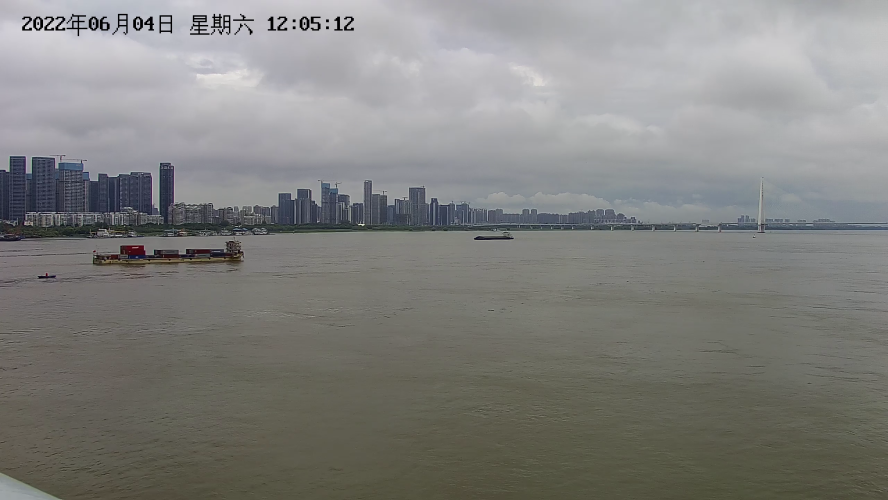

In [8]:
Image.fromarray(result[:,:,::-1])

In [9]:
import glob

files = glob.glob(r"clip-01/camera_para.txt")
print(files)


['clip-01/camera_para.txt']


In [10]:
import glob

files = glob.glob(r"clip-01/camera_para.txt")

if not files:
    print("File not found!")
else:
    with open(files[0], "r") as f:
        camera_para = f.readlines()[0][1:-2]
        camera_para = camera_para.split(',')
        camera_para = list(map(float, camera_para))


In [11]:
camera_para

[114.32722222222222,
 30.60027777777778,
 352.0,
 -4.0,
 20.0,
 55.0,
 30.94,
 2391.26,
 2446.89,
 1305.04,
 855.21]

In [12]:
import pandas as pd
path = 'clip-01/ais/2022_06_04_12_05_12.csv'
ais_data = pd.read_csv(path, usecols=[1, 2, 3, 4, 5, 6, 7, 8], header=0)

In [13]:
ais_data


,mmsi,lon,lat,speed,course,heading,type,timestamp
0,110000000,114.325830,30.601158,0.9,142.5,511,18,1654315502004
1,130000000,114.319323,30.615373,0.1,120.0,203,3,1654315422867
2,140000000,114.332392,30.616292,8.4,48.1,511,18,1654315019171
3,150000000,114.307825,30.596593,2.8,222.5,511,18,1654315505722
4,160000000,114.317922,30.614342,0.0,0.0,511,18,1654315292055
5,200000000,114.317772,30.614052,0.1,126.1,126,18,1654315334484
6,210000000,114.320187,30.606670,3.8,214.3,511,18,1654315472852
7,220000000,114.317220,30.603828,2.3,219.8,219,1,1654315464601
8,230000000,114.299270,30.583418,3.4,199.3,511,18,1654315224349
9,240000000,114.297535,30.580717,3.2,205.6,0,1,1654314955433


In [ ]:
!pip install numpy utils

In [14]:
import sys
sys.path.append(r"")



In [15]:
import sys
sys.path.append(r"/DeepSORVF")


In [1]:
import sys
sys.path.append('')
from utils.file_read import read_all, ais_initial, update_time, time2stamp



C:\Users\AIS-DT-Power4\PycharmProjects\PythonProject1\DeepSORVF\utils\file_read.py:28: SyntaxWarning: invalid escape sequence '\.'
  v_p = re.split('[\.\-\_\\\\/]',video_path)


In [20]:
import os
os.chdir('')

OSError: [WinError 123] The filename, directory name, or volume label syntax is incorrect: ''

In [11]:
import sys
import os

project_path = r"C:\Users\AIS-DT-Power4\PycharmProjects\PythonProject1\DeepSORVF"
sys.path.append(project_path)


In [16]:
import os
print(os.path.exists("utils/file_read.py"))
print(os.listdir("utils")[:50])


True
['AIS_utils.py', 'draw.py', 'draw_org.py', 'file_read.py', 'FUS_utils.py', 'gen_result.py', 'VIS_utils.py', '__init__.py']


In [17]:
import sys, os

project_path = r"C:\Users\AIS-DT-Power4\PycharmProjects\PythonProject1\DeepSORVF"
print("exists:", os.path.isdir(project_path))
print("cwd:", os.getcwd())
print("in sys.path:", project_path in sys.path)
print("sys.path[0:5]:", sys.path[:5])


exists: True
cwd: C:\Users\AIS-DT-Power4\PycharmProjects\PythonProject1\DeepSORVF
in sys.path: False
sys.path[0:5]: ['C:\\Program Files\\JetBrains\\PyCharm 2025.3.2\\plugins\\python-ce\\helpers\\jupyter_debug', 'C:\\Program Files\\JetBrains\\PyCharm 2025.3.2\\plugins\\python-ce\\helpers\\pydev', 'C:\\Users\\AIS-DT-Power4\\PycharmProjects\\PythonProject1', 'C:\\Users\\AIS-DT-Power4\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\AIS-DT-Power4\\AppData\\Local\\Programs\\Python\\Python312\\DLLs']


In [18]:
# read data
from utils.file_read import read_all, ais_initial, update_time, time2stamp

# AIS Video Fusion package
from utils.AIS_utils import AISPRO
from utils.VIS_utils import VISPRO
from utils.FUS_utils import FUSPRO

# Show the fusion results on the Video
from utils.draw import DRAW

# Save the detection tracking and fusion files
from utils.gen_result import gen_result


detection_yolox/model_data/YOLOX-final.pth model, and classes loaded.


In [41]:
# Parameter Settings
data_path = './clip-01/'
result_path = './result/'
anti = 1
anti_rate = 0
video_path, ais_path, result_video, result_metric, initial_time,\
      camera_para = read_all(data_path, result_path)

# Initialization
ais_file, timestamp0, time0 = ais_initial(ais_path, initial_time)
Time = initial_time.copy()

cap = cv2.VideoCapture(video_path)
im_shape = [cap.get(3), cap.get(4)]
max_dis = min(im_shape)//2
fps = int(cap.get(5))
t = int(1000/fps)

AIS = AISPRO(ais_path, ais_file, im_shape, t) # ais path, ais file, im_shape, t
VIS = VISPRO(anti, anti_rate, t) # anti-occlusion, occlusion rate, t
FUS = FUSPRO(max_dis, im_shape, t) # max distance of matching, im_shape, t
DRA = DRAW(im_shape, t) # im_shape, t

name = 'demo'
show_size = 500
videoWriter = None
bin_inf = pd.DataFrame(columns=['ID', 'mmsi', 'timestamp', 'match'])

print('Start Time: %s || Stamp: %d || fps: %d' % (time0, timestamp0, fps))
times  = 0
time_i = 0
sum_t  = []


Start Time: 2022_06_04_12_05_12_000 || Stamp: 1654333512000 || fps: 25


In [34]:
import importlib
import utils.VIS_utils as vu
importlib.reload(vu)

<module 'utils.VIS_utils' from 'C:\\Users\\AIS-DT-Power4\\PycharmProjects\\PythonProject1\\DeepSORVF\\utils\\VIS_utils.py'>

In [ ]:
import time
import numpy as np
# running
while True:
    # read frame
    _, im = cap.read()
    if im is None:
        break
    start = time.time()

    # update timestamp
    Time, timestamp, Time_name = update_time(Time, t)
    # =============================================================================
    #  1.AIS-based trajectory extraction. The AIS data is updated every second
    # =============================================================================
    AIS_vis, AIS_cur = AIS.process(camera_para, timestamp, Time_name)
    # =============================================================================
    #  2.Video-based trajectory extraction.
    # =============================================================================
    Vis_tra, Vis_cur = VIS.feedCap(im, timestamp, AIS_vis, bin_inf)
    # =============================================================================
    #  3.AIS/Video fusion
    # =============================================================================
    Fus_tra, bin_inf = FUS.fusion(AIS_vis, AIS_cur, Vis_tra, Vis_cur, timestamp)

    end = time.time() - start
    time_i = time_i + end
    if timestamp % 1000 < t:
        # Generate detection.txt tracking.txt fusion.txt
        gen_result(times, Vis_cur, Fus_tra, result_metric, im_shape)
        times = times+1
        sum_t.append(time_i)
        print('Time: %s || Stamp: %d || Process: %.6f || Average: %.6f +- %.6f'%(Time_name, timestamp, time_i, np.mean(sum_t), np.std(sum_t)))
        time_i = 0
    # =============================================================================
    #  4.Fusion result visualization
    # =============================================================================
    im = DRA.draw_traj(im, AIS_vis, AIS_cur, Vis_tra, Vis_cur, Fus_tra, timestamp)
    # =============================================================================
    #  Video display
    # =============================================================================
    result = im
    result = imutils.resize(result, height=show_size)
    if videoWriter is None:
        fourcc = cv2.VideoWriter_fourcc(
                'm', 'p', '4', 'v')
        videoWriter = cv2.VideoWriter(
                result_video, fourcc, fps, (result.shape[1], result.shape[0]))

    videoWriter.write(result)

    cv2.imshow(name, result)
    cv2.waitKey(1)
    if cv2.getWindowProperty(name, cv2.WND_PROP_AUTOSIZE) < 1:
    # x exist
        break
cap.release()
videoWriter.release()
cv2.destroyAllWindows()

In [36]:
import utils.AIS_utils as au
print("AIS_utils imported from:", au.__file__)


AIS_utils imported from: C:\Users\AIS-DT-Power4\PycharmProjects\PythonProject1\DeepSORVF\utils\AIS_utils.py


In [ ]:
import inspect, re
import utils.AIS_utils as au

src = inspect.getsource(au)
matches = re.findall(r"\.append\(", src)
print("Number of .append() left:", len(matches))

# show a few lines around occurrences
for m in re.finditer(r"\.append\(", src):
    start = max(0, m.start() - 80)
    end = min(len(src), m.start() + 120)
    print("\n--- context ---")
    print(src[start:end])


In [38]:
import importlib
import utils.AIS_utils as au
importlib.reload(au)


<module 'utils.AIS_utils' from 'C:\\Users\\AIS-DT-Power4\\PycharmProjects\\PythonProject1\\DeepSORVF\\utils\\AIS_utils.py'>

In [47]:
from utils.AIS_utils import AISPRO  # re-import after reload


In [ ]:
import importlib
import utils.AIS_utils as au

# 1) reload module code
importlib.reload(au)

# 2) re-bind the class name to the reloaded one
AISPRO = au.AISPRO

# 3) IMPORTANT: re-create the object (old one keeps old code)
AIS = AISPRO(ais_path, ais_file, im_shape, t)

print("Recreated AIS from:", au.__file__)


In [ ]:
import torch
print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())


In [ ]:
import torch
print("GPU:", torch.cuda.get_device_name(0))
print("Compute capability:", torch.cuda.get_device_capability(0))  # e.g. (8, 6) or (8, 9) etc.


In [ ]:
!pip uninstall -y torch torchvision torchaudio
!pip cache purge


In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128


In [ ]:
import torch
print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("arch list:", torch.cuda.get_arch_list())
print(torch.randn(1, device="cuda"))


In [ ]:
import torch, sys
print("python:", sys.executable)
print("torch:", torch.__version__)
print("torch file:", torch.__file__)
print("torch cuda:", torch.version.cuda)
print("arch list:", torch.cuda.get_arch_list())
